This notebook is only to see the catboost regressor of the RNAseq z-score combat (withour ridge)

In [1]:
import pandas as pd
from ydata_profiling import ProfileReport
import getting_threshold_genes as gtg
from sklearn.model_selection import train_test_split
import model as m
import divide_bins as divide
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef
from ydata_profiling import ProfileReport
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
import feature_selection as fs
import pickle

2024-09-27 18:32:59.511463: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-27 18:32:59.513521: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-27 18:32:59.539938: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-27 18:32:59.540038: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-27 18:32:59.541299: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
def plot_results(results, labels, print_label='Experiment'):
# Define the custom palette
    custom_palette = {
        'GSE164471': 'red',
        'GSE157585': 'blue',
        'GSE167186': 'green',
        'GSE129643': 'purple',
        'GSE60590': 'orange',
        'GSE152558': 'yellow'
    }

    label_order = ['GSE164471', 'GSE157585', 'GSE167186', 'GSE129643', 'GSE60590', 'GSE152558']


    # Assuming 'print_label' is the column name for experiments
    experiment_column = labels[print_label].values
    results[print_label] = experiment_column
    print(results)

    # Create scatter plot with custom palette
    sns.scatterplot(x='Actual', y='Predicted', hue=print_label, data=results, palette=custom_palette, hue_order=label_order, alpha=0.8, edgecolor='w')

    plt.legend()
    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.gca().set_ylim(bottom=15, top=100)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.show()

In [3]:
fit=False

In [3]:
eigth_bins = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_Combat_z_score_Train_set_SMOTE_noise.csv")
eigth_bins.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
0,-0.027742,-0.032481,0.000939,-0.029697,-0.029711,-0.031883,-0.022563,-0.028709,-0.023524,-0.027502,...,-0.032549,-0.032346,-0.032538,-0.032025,-0.031420,-0.032510,-0.032550,-0.029729,-0.032295,75.0
1,-0.018289,-0.024834,-0.002716,-0.023411,-0.023441,-0.024564,-0.019551,-0.022235,-0.020411,-0.022674,...,-0.024891,-0.024734,-0.024860,-0.024787,-0.024783,-0.024865,-0.024898,-0.027481,-0.024701,85.0
2,-0.023552,-0.027343,-0.007636,-0.025816,-0.025592,-0.026353,-0.021507,-0.020810,-0.022853,-0.023725,...,-0.027358,-0.027431,-0.027354,-0.027349,-0.026726,-0.027418,-0.027347,-0.025376,-0.026991,51.0
3,-0.029005,-0.033401,0.000583,-0.028778,-0.029956,-0.033116,-0.027197,-0.028614,-0.024847,-0.028604,...,-0.033467,-0.033467,-0.033456,-0.033327,-0.031928,-0.033431,-0.033467,-0.030221,-0.033333,71.0
4,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,-0.024588,...,-0.030232,-0.030294,-0.030216,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,55.0


In [5]:
ridge_selection = f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/feature_selection/RNAseq/feature_importance_smote_ridge_7b_top_genes_elbow.csv"
df = pd.read_csv(ridge_selection)
rnaseq_genes = df["Ensembl"]
len(rnaseq_genes)


345

In [6]:
rnaseq_genes = rnaseq_genes.to_list()

rnaseq_genes.append("Age")


In [7]:
eigth_bins_filteres = eigth_bins[rnaseq_genes]


In [8]:
del eigth_bins

In [9]:
seq_y_train_cat_a=eigth_bins_filteres["Age"]
if isinstance(seq_y_train_cat_a[0], str):
    seq_y_train_a = pd.Series(seq_y_train_cat_a).str.split('-')
    seq_y_train_a = seq_y_train_a.apply(lambda x: (int(x[0]) + int(x[1])) / 2)
else:
    seq_y_train_a = seq_y_train_cat_a



dataset = eigth_bins_filteres.copy()
dataset["Age"]=seq_y_train_a
dataset.head()

,ENSG00000004848.7,ENSG00000009307.15,ENSG00000015479.18,ENSG00000022267.16,ENSG00000036448.9,ENSG00000060138.12,ENSG00000060237.16,ENSG00000067225.17,ENSG00000069275.12,ENSG00000069869.15,...,ENSG00000270225.1,ENSG00000270672.1,ENSG00000271924.1,ENSG00000271974.1,ENSG00000273079.5,ENSG00000278395.1,ENSG00000280646.2,ENSG00000281420.1,ENSG00000285057.1,Age
0,-0.020335,0.925660,0.081321,5.322442,0.079775,2.606294,0.049142,0.836980,0.437651,0.189459,...,-0.022634,0.670842,0.008959,0.091197,-0.006018,-0.013407,-0.020310,-0.023895,-0.017501,75.0
1,-0.022005,0.855377,0.067027,4.287403,0.075192,2.622006,0.045708,0.683170,0.534944,0.171144,...,-0.022313,0.535495,0.005939,0.067669,-0.009987,-0.015844,-0.020624,-0.021849,-0.018908,85.0
2,-0.021403,0.701233,0.061998,3.453067,0.069408,1.653155,0.021387,0.548382,0.351229,0.164695,...,-0.030259,-0.014337,0.013938,-0.119816,-0.054643,-0.053448,-0.045149,-0.009168,-0.026725,51.0
3,-0.022462,1.034687,0.079096,5.864037,0.089164,2.804815,0.055610,1.041494,0.425243,0.187488,...,-0.023140,0.669216,0.009433,0.079552,-0.006514,-0.013906,-0.020821,-0.024484,-0.017756,71.0
4,-0.023153,0.972807,0.066528,3.947217,0.051263,1.814003,0.107088,0.604580,0.365777,0.139188,...,-0.034240,1.571977,-0.058816,-0.043119,-0.053028,-0.053673,-0.046466,-0.040760,0.011211,55.0


In [10]:
class optimize:
    def __init__(self,train_data, n_trials=50):
        X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(train_data, test_size=0.2)
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.n_trials = n_trials
    def optimize(self):
        study = optuna.create_study(direction='minimize')  # Maximize accuracy
        study.optimize(self.objective, n_trials=self.n_trials) 
    def objective(self, trial):
        # Define hyperparameters to optimize
        params = {
            'iterations': trial.suggest_int('iterations', 50, 1000),
            'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.01),
            'depth': trial.suggest_int('depth', 2, 5),
            'random_state': 42,  # Fixed random state
            'verbose': 0,  # Fixed verbosity
            'od_type': 'Iter',  # Early stopping type
            'od_wait': 5,  # Early stopping patience
            #'eval_metric': 'RMSE'  # Metric to optimize

        }
        params = {
        'iterations': trial.suggest_int('iterations', 50, 100),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.01),
        'depth': trial.suggest_int('depth', 2, 5),  # Modify depth range to match the original
        'verbose': 0,  # Fixed verbosity
        'od_type': 'Iter',  # Early stopping type
        'od_wait': 5,  # Early stopping patience
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.0, 10.0),  # L2 regularization coefficient
        #'sampling_frequency': trial.suggest_categorical('sampling_frequency', ['PerTree', 'PerTreeLevel', 'PerTreeNode']),  # Frequency of sampling
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),  # Random strength
        #'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),  # Tree growth policy
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),  # Minimum number of samples in leaf
        #'boosting_type': trial.suggest_categorical('boosting_type', ['Ordered', 'Plain']),  # Type of boosting
        'score_function': trial.suggest_categorical('score_function', ['Cosine', 'L2']),  # Metric to use
        'penalties_coefficient': trial.suggest_float('penalties_coefficient', 0.0, 10.0),  # Penalty coefficient
        'model_shrink_rate': trial.suggest_float('model_shrink_rate', 0.0, 1.0),  # Model shrink rate
        #'model_shrink_mode': trial.suggest_categorical('model_shrink_mode', ['Constant', 'ShrinkToBest', 'ShrinkToRandom']),  # Model shrink mode
        'eval_metric': 'RMSE'  # Metric to optimize
    }

        # Initialize classifier with the suggested hyperparameters
        regressor = CatBoostRegressor(**params)

        # Fit the model
        regressor.fit(self.X_train, self.y_train, eval_set=(self.X_test, self.y_test), use_best_model=True)
        # Make predictions
        y_pred = regressor.predict(self.X_test)
        # Calculate rmse
        rmse = mean_squared_error(self.y_test, y_pred, squared=False)
        return rmse


In [11]:

optimize = optimize(train_data = dataset, n_trials=20)
#params = optimize.optimize()
#params

In [12]:

if fit:
    x = optimize.optimize()
    print(x)

In [11]:
params = {'iterations': 2000, 'learning_rate': 0.0057754728847108075, 'depth': 4, 'l2_leaf_reg': 1.4995313057538833, 'random_strength': 3.6144926272336773, 'min_data_in_leaf': 33, 'score_function': 'Cosine', 'penalties_coefficient': 7.492437722110218, 'model_shrink_rate': 0.0036095159058368662}
#params = {'iterations': 2000, 'learning_rate': 0.00984211577545461, 'depth': 2, 'l2_leaf_reg': 9.709291858633904, 'random_strength': 4.545211685851626, 'min_data_in_leaf': 49, 'score_function': 'Cosine', 'penalties_coefficient': 4.226444903400312, 'model_shrink_rate': 0.28139372449907607}
#params = {'iterations': 2000, 'learning_rate': 0.009859735066518074, 'depth': 4, 'l2_leaf_reg': 5.8874298860436625, 'random_strength': 9.492374563806697, 'min_data_in_leaf': 39, 'score_function': 'Cosine', 'penalties_coefficient': 0.004695591273947031, 'model_shrink_rate': 0.003428442640894508}

In [15]:
X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(dataset, test_size=0.3)
#random_strength

# Initialize CatBoostClassifier
seq_regressor = CatBoostRegressor(**params) 

# Fit the model
if fit:
    seq_regressor.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 23.3761120	test: 22.6420149	best: 22.6420149 (0)	total: 64.5ms	remaining: 2m 8s
1:	learn: 23.2823370	test: 22.5510970	best: 22.5510970 (1)	total: 71.7ms	remaining: 1m 11s
2:	learn: 23.1881980	test: 22.4571734	best: 22.4571734 (2)	total: 76.4ms	remaining: 50.9s
3:	learn: 23.0956942	test: 22.3690757	best: 22.3690757 (3)	total: 81ms	remaining: 40.4s
4:	learn: 23.0183871	test: 22.2971402	best: 22.2971402 (4)	total: 84.6ms	remaining: 33.8s
5:	learn: 22.9178306	test: 22.1996015	best: 22.1996015 (5)	total: 89.1ms	remaining: 29.6s
6:	learn: 22.8283540	test: 22.1178235	best: 22.1178235 (6)	total: 92.9ms	remaining: 26.5s
7:	learn: 22.7519229	test: 22.0440923	best: 22.0440923 (7)	total: 98ms	remaining: 24.4s
8:	learn: 22.6663009	test: 21.9601359	best: 21.9601359 (8)	total: 102ms	remaining: 22.5s
9:	learn: 22.6096597	test: 21.9063051	best: 21.9063051 (9)	total: 106ms	remaining: 21.2s
10:	learn: 22.5120272	test: 21.8110523	best: 21.8110523 (10)	total: 113ms	remaining: 20.4s
11:	learn: 22.

In [16]:
if fit:
    # Specify the file path where you want to save the pickle file
    file_path = '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_2_7_Catboost_n_Ridge.pkl'

    # Save the seq_regressor variable in the pickle file
    with open(file_path, 'wb') as f:
        pickle.dump(seq_regressor, f)
else:

    # Specify the file path where the pickle file is located
    file_path = '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_2_7_Catboost_n_Ridge.pkl'

    # Load the seq_regressor object from the pickle file
    with open(file_path, 'rb') as f:
        seq_regressor = pickle.load(f)

    # Now you can use the seq_regressor object in your code


In [17]:
# Make predictions
y_pred = seq_regressor.predict(X_test)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test, y_pred)
seq_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
seq_mse

22.45607385462514

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate R2
r2 = r2_score(y_test, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 22.45607385462514
RMSE: 4.7387840059054325
MAE: 3.170252728797666
R2: 0.9564524341545089


In [19]:
age_ranges_list=[18, 26, 35, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(y_test, age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 15},
 {'label': '26-35', 'range': (26, 35), 'count': 13},
 {'label': '35-65', 'range': (35, 65), 'count': 14},
 {'label': '65-71', 'range': (65, 71), 'count': 6},
 {'label': '71-72', 'range': (71, 72), 'count': 2},
 {'label': '72-95', 'range': (72, 95), 'count': 19}]

In [20]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[14,  1,  0,  0,  0,  0],
       [ 0, 10,  3,  0,  0,  0],
       [ 0,  0, 14,  0,  0,  0],
       [ 0,  0,  0,  4,  1,  1],
       [ 0,  0,  0,  0,  2,  0],
       [ 0,  0,  2,  5,  2, 10]])

In [21]:
seq_auc=accuracy_score(c_y_test.round(0), c_y_pred.round(0))
seq_auc

0.782608695652174

In [22]:
y_test

68     22.0
12     59.0
126    74.0
166    24.0
156    69.0
       ... 
130    34.0
165    24.0
66     84.0
151    72.0
164    25.0
Name: Age, Length: 69, dtype: float64

In [23]:
seq_results

,Actual,Predicted
68,22.0,24.215838
12,59.0,52.290137
126,74.0,69.384427
166,24.0,22.111804
156,69.0,68.472789
...,...,...
130,34.0,29.523095
165,24.0,22.746483
66,84.0,79.135640
151,72.0,71.396439


/tmp/ipykernel_827662/659211106.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


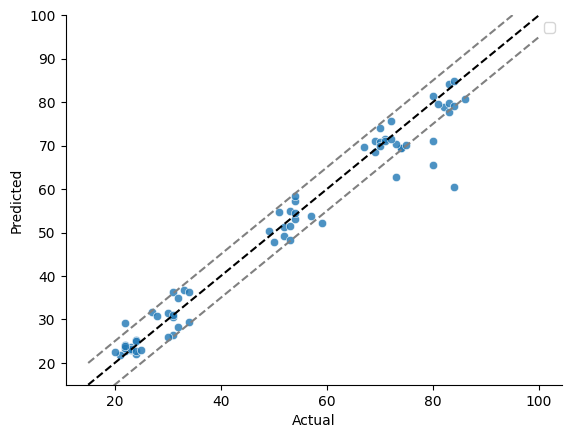

In [24]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [25]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[14,  1,  0,  0,  0,  0],
       [ 0, 10,  3,  0,  0,  0],
       [ 0,  0, 14,  0,  0,  0],
       [ 0,  0,  0,  4,  1,  1],
       [ 0,  0,  0,  0,  2,  0],
       [ 0,  0,  2,  5,  2, 10]])

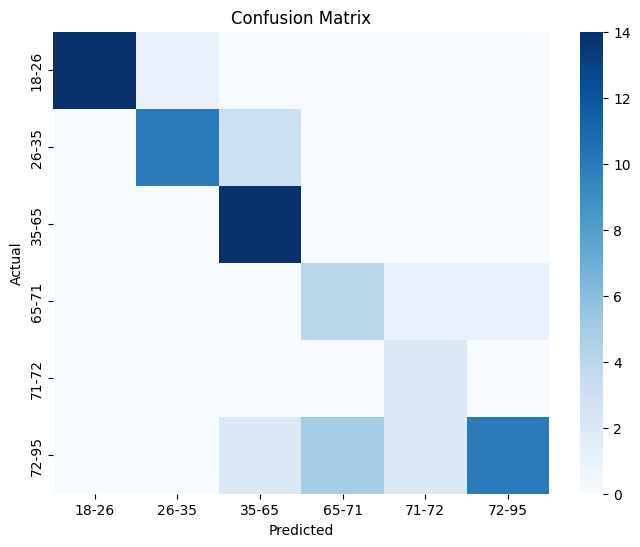

In [26]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [28]:
eigth_bins_test = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_Combat_z_score_Test_set.csv")
eigth_bins_test.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age,Status,Experiment,Age.1,Sample,Sex
0,-0.022233,-0.024446,-0.006216,-0.024515,-0.023171,-0.023202,-0.019452,-0.021846,-0.022867,-0.023905,...,-0.024472,-0.024526,-0.023199,-0.024432,24.0,Healthy,GSE157585,24.0,SRR12604218,NaN
1,-0.023307,-0.025360,-0.006206,-0.022286,-0.022653,-0.024454,-0.018532,-0.020077,-0.018804,-0.020995,...,-0.025252,-0.025311,-0.024447,-0.025087,18.0,Healthy,GSE167186,18.0,SRR13759023,NaN
2,-0.027950,-0.030171,-0.006227,-0.026315,-0.025683,-0.028757,-0.020073,-0.022860,-0.020748,-0.024276,...,-0.029934,-0.029985,-0.022886,-0.029776,23.0,Healthy,GSE167186,23.0,SRR13759025,NaN
3,-0.024681,-0.028953,-0.002464,-0.027633,-0.027815,-0.027149,-0.019945,-0.025554,-0.020408,-0.027101,...,-0.028774,-0.028772,-0.027571,-0.028812,26.4,untrained,GSE60590,26.4,SRR1555206,female
4,-0.021846,-0.026700,0.003155,-0.022868,-0.023732,-0.026121,-0.013602,-0.018935,-0.015076,-0.019944,...,-0.026722,-0.026784,-0.025465,-0.026577,71.0,Healthy,GSE157585,71.0,SRR12604184,NaN


In [29]:
age_ranges_list=[18, 26, 35, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(eigth_bins_test["Age"], age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 13},
 {'label': '26-35', 'range': (26, 35), 'count': 23},
 {'label': '35-65', 'range': (35, 65), 'count': 17},
 {'label': '65-71', 'range': (65, 71), 'count': 9},
 {'label': '71-72', 'range': (71, 72), 'count': 25},
 {'label': '72-95', 'range': (72, 95), 'count': 21}]

In [34]:
X_test_untoached = eigth_bins_test.drop(columns=["Age"])
X_test_untoached.drop(columns=["Experiment", "Sample", "Status", "Age.1", "Sex"], inplace=True)
y_test_untoached = eigth_bins_test["Age"]
seq_z_test = eigth_bins_test["Experiment"]

In [35]:
seq_z_test = pd.DataFrame(seq_z_test)
seq_z_test.columns = ["Experiment"]

In [36]:
# Make predictions
y_pred = seq_regressor.predict(X_test_untoached)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test_untoached, y_pred)
seq_results = pd.DataFrame({'Actual': y_test_untoached, 'Predicted': y_pred})
seq_mse

45.2043559743261

/tmp/ipykernel_827662/1353933196.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


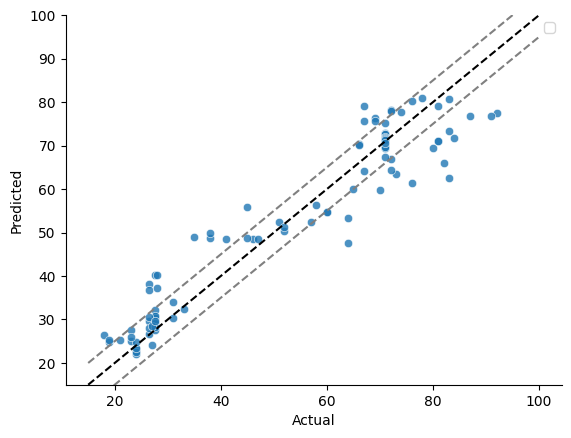

In [46]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.savefig("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/Catboost_Ridge_regression_smote_untoached.png")
plt.show()

     Actual  Predicted Experiment
0      24.0  22.716666  GSE157585
1      18.0  26.491389  GSE167186
2      23.0  25.159397  GSE167186
3      26.4  38.104758   GSE60590
4      71.0  71.649501  GSE157585
..      ...        ...        ...
103    71.0  71.373699  GSE157585
104    23.0  26.069014  GSE167186
105    72.0  77.917377  GSE164471
106    71.0  70.585552  GSE157585
107    71.0  75.132440  GSE167186

[108 rows x 3 columns]


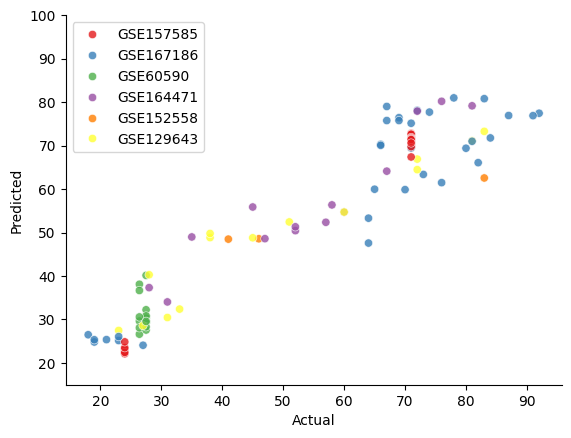

In [38]:
m.plot_results(results=seq_results, labels=seq_z_test)

In [39]:
c_y_test = pd.Series(y_test_untoached).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[10,  3,  0,  0,  0,  0],
       [ 1, 17,  5,  0,  0,  0],
       [ 0,  0, 17,  0,  0,  0],
       [ 0,  0,  3,  2,  0,  4],
       [ 0,  0,  0, 10,  9,  6],
       [ 0,  0,  4,  4,  2, 11]])

In [40]:
acu = accuracy_score(c_y_test, c_y_pred)
acu

0.6111111111111112

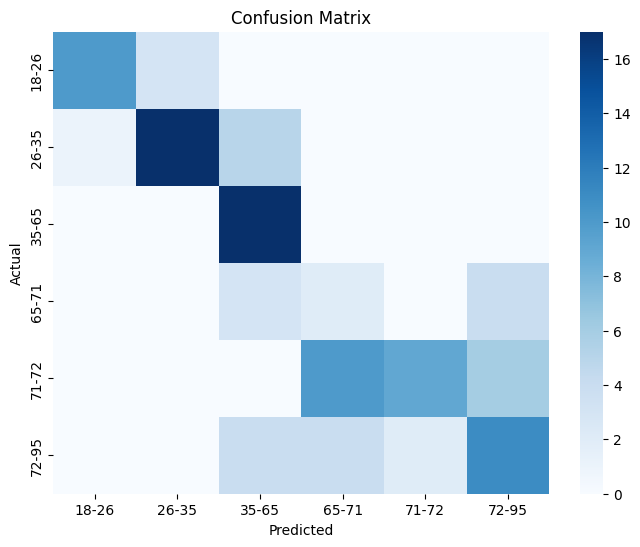

In [41]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("RNAs_z_Combat_2_8_Ridge_seq_confusion_matrix.png")
plt.show()

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test_untoached, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test_untoached, y_pred)

# Calculate R2
r2 = r2_score(y_test_untoached, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 45.2043559743261
RMSE: 6.723418473836513
MAE: 4.8953102729543945
R2: 0.9097099241329943


In [43]:
explainer = shap.Explainer(seq_regressor)
shap_values = explainer.shap_values(X_test)
importance = seq_regressor.get_feature_importance()
feature_imporance_df = pd.DataFrame(importance, index=X_test.columns, columns=["importance"])
feature_imporance_df=feature_imporance_df[feature_imporance_df["importance"] > 0]
feature_imporance_df = feature_imporance_df.sort_values(by="importance", ascending=False)
feature_imporance_df

,importance
ENSG00000156298.12,5.725900
ENSG00000164879.6,3.698251
ENSG00000171055.14,2.452980
ENSG00000234441.1,2.272484
ENSG00000222346.1,2.115887
...,...
ENSG00000252745.1,0.013602
ENSG00000135404.11,0.012527
ENSG00000099139.13,0.012412
ENSG00000248126.1,0.012082


In [44]:
feature_imporance_df.head(50)

,importance
ENSG00000156298.12,5.725900
ENSG00000164879.6,3.698251
ENSG00000171055.14,2.452980
ENSG00000234441.1,2.272484
ENSG00000222346.1,2.115887
ENSG00000186591.11,1.870659
ENSG00000103145.10,1.785784
ENSG00000113916.17,1.692976
ENSG00000198034.10,1.634889
ENSG00000135821.18,1.556093


In [45]:
feature_imporance_df.to_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/feature_selection/RNAs_z_Combat_2_7_Catboost_Ridge_regressor_genes_importance.csv")

In [46]:
gene_names = [
("ENSG00000101892.11","ATP1B4"),
("ENSG00000201766.1","RNA5SP302"),
("ENSG00000127241.16","MASP1"),
("ENSG00000277654.5","AC087633.2"),
("ENSG00000145949.10","MYLK4"),
("ENSG00000171055.14","FEZ2"),
("ENSG00000198712.1","MT-CO2"),
("ENSG00000164104.11","HMGB2"),
("ENSG00000172399.5","MYOZ2"),
("ENSG00000177548.12","RABEP2"),
("ENSG00000089101.17","CFAP61"),
("ENSG00000003989.17","SLC7A2"),
("ENSG00000137700.17","SLC37A4"),
("ENSG00000174227.15","PIGG"),
("ENSG00000133020.4","MYH8"),
("ENSG00000252262.1","RNA5SP61"),
("ENSG00000234441.1","AC105272.1"),
("ENSG00000247627.2","MTND4P12"),
("ENSG00000100568.10","VTI1B"),
("ENSG00000237973.1","MTCO1P12"),
("ENSG00000170873.18","MTSS1"),
("ENSG00000082397.17"	,"EPB41L3"),
("ENSG00000111640.14"	,"GAPDH"),
    ("ENSG00000035664.11", "DAPK2"),
    ("ENSG00000160294.10", "MCM3AP"),
    ("ENSG00000197111.15", "PCBP2"),
    ("ENSG00000250479.8", "CHCHD10"),
    ("ENSG00000105323.16", "HNRNPUL1"),
    ("ENSG00000167186.10", "COQ7"),
    ("ENSG00000197563.10", "PIGN"),
    ("ENSG00000252598.1", "RNA5SP460"),
    ("ENSG00000276045.3", "ORAI1"),
    ("ENSG00000172889.15", "EGFL7"),
    ("ENSG00000144021.2", "CIAO1"),
    ("ENSG00000172159.15", "FRMD3"),
    ("ENSG00000143549.19", "TPM3"),
    ("ENSG00000139197.10", "PEX5"),
    ("ENSG00000069869.15", "NEDD4"),
    ("ENSG00000164093.16", "PITX2"),
    ("ENSG00000196781.14", "TLE1"),
    ("ENSG00000213923.11", "CSNK1E"),
    ("ENSG00000162735.18", "PEX19"),
    ("ENSG00000148219.16", "ASTN2"),
    ("ENSG00000189403.14", "HMGB1"),
    ("ENSG00000201440.1", "RNA5SP515"),
    ("ENSG00000171867.16", "PRNP"),
    ("ENSG00000257542.5", "OR7E47P"),
    ("ENSG00000146147.14", "MLIP"),
    ("ENSG00000062485.18", "CS"),
    ("ENSG00000252650.1", "RNA5SP75"),
    ("ENSG00000260914.3", "AC026464.4"),
    ("ENSG00000272006.1", "AC037487.3"),
    ("ENSG00000185915.5", "KLHL34"),
    ("ENSG00000177548.12", "RABEP2"),
    ("ENSG00000197223.11", "C1D"),
    ("ENSG00000072163.19", "LIMS2"),
    ("ENSG00000163864.16", "NMNAT3"),
    ("ENSG00000151338.18", "MIPOL1"),
    ("ENSG00000232177.1", "MTND4P24"),
    ("ENSG00000167244.19", "IGF2"),
    ("ENSG00000122218.14", "COPA"),
    ("ENSG00000252376.1", "RNA5SP395"),
    ("ENSG00000187642.9", "PERM1"),
    ("ENSG00000136111.12", "TBC1D4"),
    ("ENSG00000123095.5", "BHLHE41"),
    ("ENSG00000095787.21", "WAC"),
    ("ENSG00000169057.21", "MECP2"),
    ("ENSG00000132530.16", "XAF1"),
    ("ENSG00000202411.1", "RNA5SP259"),
    ("ENSG00000173212.4", "MAB21L3"),
    ("ENSG00000020577.13", "SAMD4A"),
    ("ENSG00000185760.15", "KCNQ5"),
    ("ENSG00000248422.1", "AC233724.3")

]


for gene_id, gene_name in gene_names:
    if gene_id in X_test.columns:
        X_test.rename(columns={gene_id: gene_name}, inplace=True)


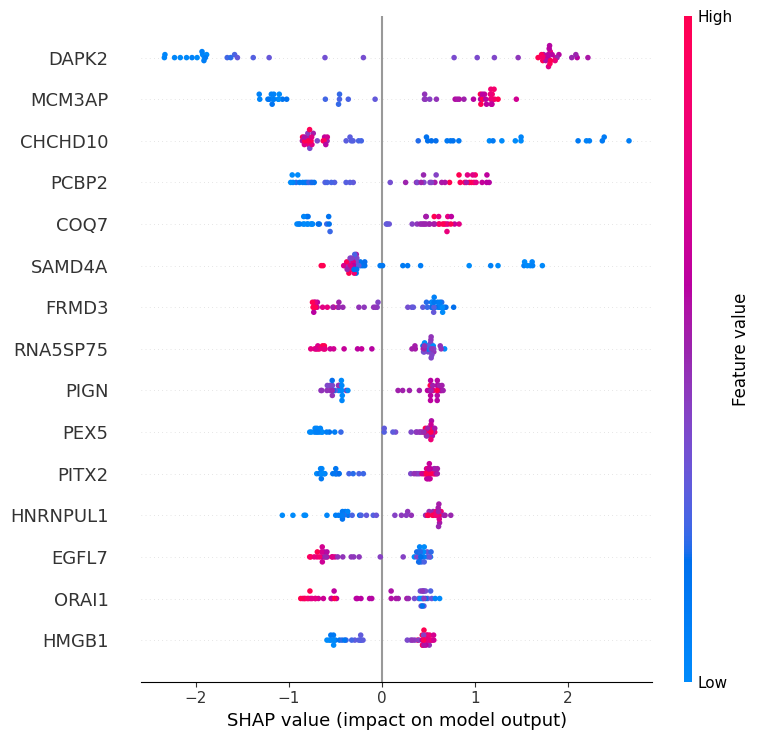

In [ ]:
shap.summary_plot(shap_values, X_test, max_display=15)


In [45]:
mcc = matthews_corrcoef(c_y_test, c_y_pred)
mcc

0.6003804269405586